# Implementacja modelu Vanilla GAN
Publikacja: https://arxiv.org/pdf/1406.2661.pdf

In [1]:
# Uwaga: ten przykład skupia się na implementacji procesu trenowania sieci GAN
# używamy najprostszego modelu neuronowego - gęstych warstw liniowych

In [2]:
!pip install torch torchvision numpy 

  Using cached torch-2.11.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (29 kB)
  Using cached torchvision-0.26.0-cp313-cp313-macosx_12_0_arm64.whl.metadata (5.5 kB)
  Using cached numpy-2.4.4-cp313-cp313-macosx_14_0_arm64.whl.metadata (6.6 kB)
  Using cached filelock-3.28.0-py3-none-any.whl.metadata (2.0 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached setuptools-81.0.0-py3-none-any.whl.metadata (6.6 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
  Using cached fsspec-2026.3.0-py3-none-any.whl.metadata (10 kB)
  Using cached pillow-12.2.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached markupsafe-3.0.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (2.7 kB)
Using cached torch-2.11.0-cp313-cp313-macosx_11_0_arm64.whl (80.

In [3]:
import torch
import torchvision
import torch.nn as nn
import torch.nn.functional as F

In [4]:
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision import transforms
from torchvision.utils import save_image

In [5]:
import numpy as np
import datetime
import os, sys

In [6]:
from matplotlib.pyplot import imshow, imsave
%matplotlib inline

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
MODEL_NAME = 'vanilla-GAN'
DEVICE = torch.device("mps" if torch.mps.is_available() else "cpu")
print(DEVICE)

mps


In [ ]:
# generowanie próbki fałszywych obrazów przez próbkowanie szumu
def get_sample_image(G, n_noise):
    z = torch.randn(100, n_noise).to(DEVICE)
    y_hat = G(z).view(100, 28, 28) # (100, 28, 28)
    result = y_hat.cpu().data.numpy()
    img = np.zeros([280, 280])
    for j in range(10):
        img[j*28:(j+1)*28] = np.concatenate([x for x in result[j*10:(j+1)*10]], axis=-1)
    return img

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, input_size=784, num_classes=1):
        super(Discriminator, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, num_classes),
            nn.Sigmoid(),
        )

    def forward(self, x):
        y_ = x.view(x.size(0), -1)
        y_ = self.layer(y_)
        return y_

In [ ]:
class Generator(nn.Module):
    def __init__(self, input_size=100, num_classes=784):
        super(Generator, self).__init__()
        self.layer = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, num_classes),
            nn.Tanh()
        )

    def forward(self, x):
        y_ = self.layer(x)
        y_ = y_.view(x.size(0), 1, 28, 28)
        return y_

In [ ]:
n_noise = 100

In [ ]:
D = Discriminator().to(DEVICE)
G = Generator(n_noise).to(DEVICE)

In [ ]:
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize(mean=[0.5],
                                std=[0.5])]
)

In [ ]:
mnist = datasets.MNIST(root='../data/', train=True, transform=transform, download=True)

In [ ]:
batch_size = 64

In [ ]:
data_loader = DataLoader(dataset=mnist, batch_size=batch_size, shuffle=True, drop_last=True)

In [ ]:
criterion = nn.BCELoss()
D_opt = torch.optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))
G_opt = torch.optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [ ]:
max_epoch = 20
step = 0
n_critic = 1 

In [ ]:
D_labels = torch.ones(batch_size, 1).to(DEVICE) # Etykieta Dyskryminatora dla prawdziwych danych
D_fakes = torch.zeros(batch_size, 1).to(DEVICE) # Etykieta Dyskryminatora dla fałszywych danych

In [ ]:
if not os.path.exists('samples'):
    os.makedirs('samples')

In [ ]:
for epoch in range(max_epoch):
    for idx, (images, _) in enumerate(data_loader):
        # Trenowanie Dyskryminatora
        x = images.to(DEVICE)
        x_outputs = D(x)
        D_x_loss = criterion(x_outputs, D_labels)

        z = torch.randn(batch_size, n_noise).to(DEVICE)
        z_outputs = D(G(z))
        D_z_loss = criterion(z_outputs, D_fakes)
        D_loss = D_x_loss + D_z_loss

        D.zero_grad()
        D_loss.backward()
        D_opt.step()

        if step % n_critic == 0:
            # Trenowanie Generatora
            z = torch.randn(batch_size, n_noise).to(DEVICE)
            z_outputs = D(G(z))
            G_loss = criterion(z_outputs, D_labels)

            G.zero_grad()
            G_loss.backward()
            G_opt.step()

        if step % 500 == 0:
            print('Epoka: {}/{}, Krok: {}, Strata D: {}, Strata G: {}'.format(epoch, max_epoch, step, D_loss.item(), G_loss.item()))

        if step % 1000 == 0:
            G.eval()
            img = get_sample_image(G, n_noise)
            imsave('samples/{}_krok{}.jpg'.format(MODEL_NAME, str(step).zfill(3)), img, cmap='gray')
            G.train()
        step += 1

Epoch: 0/20, Step: 0, D Loss: 1.4255520105361938, G Loss: 0.6840164065361023
Epoch: 0/20, Step: 500, D Loss: 1.2719694375991821, G Loss: 0.8106861710548401
Epoch: 1/20, Step: 1000, D Loss: 1.1673754453659058, G Loss: 1.001522183418274
Epoch: 1/20, Step: 1500, D Loss: 1.2520382404327393, G Loss: 0.8150149583816528
Epoch: 2/20, Step: 2000, D Loss: 1.203014850616455, G Loss: 1.0851483345031738
Epoch: 2/20, Step: 2500, D Loss: 1.4636902809143066, G Loss: 0.4396783709526062
Epoch: 3/20, Step: 3000, D Loss: 1.1635892391204834, G Loss: 1.0621302127838135
Epoch: 3/20, Step: 3500, D Loss: 1.1846437454223633, G Loss: 1.0322552919387817
Epoch: 4/20, Step: 4000, D Loss: 1.4390056133270264, G Loss: 0.5525920391082764
Epoch: 4/20, Step: 4500, D Loss: 1.1366955041885376, G Loss: 0.9968951940536499
Epoch: 5/20, Step: 5000, D Loss: 1.2535055875778198, G Loss: 0.8741185069084167
Epoch: 5/20, Step: 5500, D Loss: 1.2329990863800049, G Loss: 1.138258457183838
Epoch: 6/20, Step: 6000, D Loss: 1.338651061058

## Wizualizacja próbek

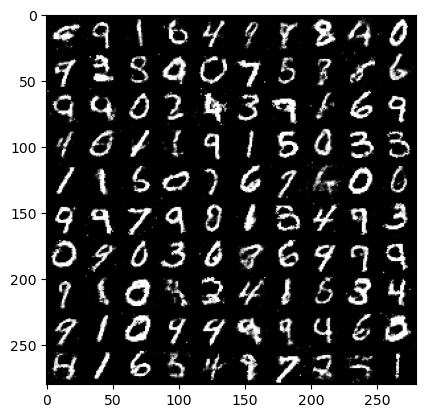

In [ ]:
# generowanie obrazu
G.eval()
imshow(get_sample_image(G, n_noise), cmap='gray')

In [ ]:
# Zapis parametrów modelu.
torch.save(D.state_dict(), 'D.pkl')
torch.save(G.state_dict(), 'G.pkl')